<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Difussion Run 1: Build CORSIKA Neutrino Flux Dataset

This notebook builds the neutrino diffusion-model dataset from CORSIKA 8 shower outputs events generated by `run3_Corsika_EventGenerator.ipynb`.

The goal is to transform many weighted CORSIKA events into gridded neutrino differential-flux tensors in energy, zenith angle, and atmospheric height:

$$
\Phi_\nu(E_\nu, \theta_\nu, h).
$$

The resulting tensors can be used as training targets for a generative diffusion model. The notebook reads generated event directories, extracts neutrinos from `particles/particles.parquet`, combines CORSIKA particle weights with the primary importance-sampling weights, bins the result on a configurable grid, and stores both raw neutrino samples and flux cubes.

## 1. Libraries

This section imports the libraries used to read the CORSIKA campaign output, build binned neutrino-flux tensors, store HDF5 datasets, and visualize the result.

In [ ]:
from __future__ import annotations
%matplotlib inline
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Any
import json
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

from tpeanuts.notebooks.notebookConfig import load_notebook_config

config = load_notebook_config()

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Section 1 smoke test: verify that the scientific stack was imported.
print(f"NumPy version: {np.__version__}")
print(f"h5py version: {h5py.__version__}")
print(f"Pandas version: {pd.__version__}")
assert np.__version__
assert h5py.__version__
assert plt is not None
import os
print(f"\nMatplotlib inline rendering is enabled in notebooks.")
print(f"Configured style: seaborn-v0_8-whitegrid")

print("\nSection 1 test passed: libraries are available.")


NumPy version: 1.26.4
h5py version: 3.14.0
Pandas version: 2.3.3

Matplotlib inline rendering is enabled in notebooks.
Configured style: seaborn-v0_8-whitegrid

Section 1 test passed: libraries are available.


## 2. Parameters

This section defines shared workflow paths and dataset-building parameters, including the target grid in neutrino energy, zenith angle, and observation height.

In [ ]:
RUN = "run_2"

OUTPUT_ROOT = config.output_root
OUTPUT_DATA_ROOT = config.output_data_root
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "corsika")
OUTPUT_DIFUSSION_ROOT = Path(OUTPUT_DATA_ROOT / "difussion")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIFUSSION_ROOT.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
PATH_MANIFEST_FILE = Path(PATH_OUTPUT_RUN / "manifest.csv")

PATH_OUTPUT_DATASET = Path(OUTPUT_DIFUSSION_ROOT / "dataset")
PATH_OUTPUT_DATASET_RUN = PATH_OUTPUT_DATASET / RUN
PATH_OUTPUT_DATASET_RUN.mkdir(parents=True, exist_ok=True)

PATH_DATASET_NEUTRINO_PARTICLES_NPZ = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_particles.npz"
PATH_DATASET_NEUTRINO_PARTICLES_PARQUET = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_particles.parquet"
PATH_DATASET_NEUTRINO_CUBES = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_cubes.h5"
PATH_DATASET_NEUTRINO_METADATA = PATH_OUTPUT_DATASET_RUN / "dataset_neutrino_metadata.json"

print(" Configured workflow paths:\n", "=" * 80)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - OUTPUT_DIFUSSION_ROOT = ", OUTPUT_DIFUSSION_ROOT)
print(" - RUN = ", RUN, "\n")
print(" - PATH_MANIFEST_FILE = ", PATH_MANIFEST_FILE)

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_DATASET_RUN                  = ", PATH_OUTPUT_DATASET_RUN)
print(" - PATH_DATASET_NEUTRINO_PARTICLES_NPZ      = ", PATH_DATASET_NEUTRINO_PARTICLES_NPZ)
print(" - PATH_DATASET_NEUTRINO_PARTICLES_PARQUET  = ", PATH_DATASET_NEUTRINO_PARTICLES_PARQUET)
print(" - PATH_DATASET_NEUTRINO_CUBES              = ", PATH_DATASET_NEUTRINO_CUBES)
print(" - PATH_DATASET_NEUTRINO_METADATA           = ", PATH_DATASET_NEUTRINO_METADATA)


In [4]:
# ==========================================================
# Energy binning
# ==========================================================

LOG10_ENERGY_MIN_GEV = -3.0
LOG10_ENERGY_MAX_GEV = 3.0
ENERGY_BINS = 48

# ==========================================================
# Zenith angle binning
# ==========================================================

THETA_MIN_DEG = 0.0
THETA_MAX_DEG = 90.0
THETA_BINS = 24

# ==========================================================
# Altitude binning
# ==========================================================

H_MIN_M = 0.0
H_MAX_M = 30_000.0
H_BINS = 16

# ==========================================================
# Detector configuration
# ==========================================================

EFFECTIVE_AREA_M2 = 1.0
EXPOSURE_TIME_S = 1.0

# ==========================================================
# Output options
# ==========================================================

KEEP_RAW_NEUTRINOS = True
MAX_EVENTS = None
EXTRACTION_MAX_WORKERS = min(32, max(1, (os.cpu_count() or 1) * 2))

# ==========================================================
# Torch-ready table output
# ==========================================================

SAVE_TORCH_PARQUET = True
SAVE_TORCH_NPZ = True

# ==========================================================
# Diffusion cube samples
# ==========================================================

CUBE_EVENTS_PER_SAMPLE = 800
CUBE_EVENT_STRIDE = 400
CUBE_MIN_NEUTRINOS = 1
CUBE_MIN_COUNTS_PER_BIN = 1
CUBE_MAX_RELATIVE_UNCERTAINTY = 1.0
CUBE_WEIGHT_COLUMN = "total_weight"
CUBE_STORE_LOG10 = True
CUBE_LOG10_FLUX_FLOOR = -12.0
CUBE_STORE_SUPPORT_TARGETS = True
CUBE_STORE_LOG1P_WEIGHTED_COUNTS = True

@dataclass(frozen=True)
class Config:
    """Configuration for neutrino-flux dataset construction."""

    runs_root: Path = Path(PATH_OUTPUT_RUN)
    manifest_path: Path = Path(PATH_MANIFEST_FILE)
    neutrino_npz_output_path: Path = Path(PATH_DATASET_NEUTRINO_PARTICLES_NPZ)
    neutrino_parquet_output_path: Path = Path(PATH_DATASET_NEUTRINO_PARTICLES_PARQUET)
    neutrino_cubes_output_path: Path = Path(PATH_DATASET_NEUTRINO_CUBES)
    neutrino_metadata_path: Path = Path(PATH_DATASET_NEUTRINO_METADATA)
    log10_energy_min_gev: float = -3.0
    log10_energy_max_gev: float = 3.0
    energy_bins: int = 72
    theta_min_deg: float = 0.0
    theta_max_deg: float = 90.0
    theta_bins: int = 45
    h_min_m: float = 0.0
    h_max_m: float = 30_000.0
    h_bins: int = 7
    effective_area_m2: float = 1.0
    exposure_time_s: float = 1.0
    keep_raw_neutrinos: bool = True
    max_events: int | None = None
    extraction_max_workers: int = EXTRACTION_MAX_WORKERS
    save_torch_parquet: bool = True
    save_torch_npz: bool = True
    cube_events_per_sample: int = 500
    cube_event_stride: int = 500
    cube_min_neutrinos: int = 1
    cube_min_counts_per_bin: int = 1
    cube_max_relative_uncertainty: float = 0.5
    cube_weight_column: str = "total_weight"
    cube_store_log10: bool = True
    cube_log10_flux_floor: float = -12.0
    cube_store_support_targets: bool = True
    cube_store_log1p_weighted_counts: bool = True


CONFIG = Config(
    runs_root                    = Path(PATH_OUTPUT_RUN),
    manifest_path                = Path(PATH_MANIFEST_FILE),
    neutrino_npz_output_path     = Path(PATH_DATASET_NEUTRINO_PARTICLES_NPZ),
    neutrino_parquet_output_path = Path(PATH_DATASET_NEUTRINO_PARTICLES_PARQUET),
    neutrino_cubes_output_path   = Path(PATH_DATASET_NEUTRINO_CUBES),
    neutrino_metadata_path       = Path(PATH_DATASET_NEUTRINO_METADATA),
    log10_energy_min_gev=LOG10_ENERGY_MIN_GEV,
    log10_energy_max_gev=LOG10_ENERGY_MAX_GEV,
    energy_bins=ENERGY_BINS,
    theta_min_deg=THETA_MIN_DEG,
    theta_max_deg=THETA_MAX_DEG,
    theta_bins=THETA_BINS,
    h_min_m=H_MIN_M,
    h_max_m=H_MAX_M,
    h_bins=H_BINS,
    effective_area_m2=EFFECTIVE_AREA_M2,
    exposure_time_s=EXPOSURE_TIME_S,
    keep_raw_neutrinos=KEEP_RAW_NEUTRINOS,
    max_events=MAX_EVENTS,
    extraction_max_workers=EXTRACTION_MAX_WORKERS,
    save_torch_parquet=SAVE_TORCH_PARQUET,
    save_torch_npz=SAVE_TORCH_NPZ,
    cube_events_per_sample=CUBE_EVENTS_PER_SAMPLE,
    cube_event_stride=CUBE_EVENT_STRIDE,
    cube_min_neutrinos=CUBE_MIN_NEUTRINOS,
    cube_min_counts_per_bin=CUBE_MIN_COUNTS_PER_BIN,
    cube_max_relative_uncertainty=CUBE_MAX_RELATIVE_UNCERTAINTY,
    cube_weight_column=CUBE_WEIGHT_COLUMN,
    cube_store_log10=CUBE_STORE_LOG10,
    cube_log10_flux_floor=CUBE_LOG10_FLUX_FLOOR,
    cube_store_support_targets=CUBE_STORE_SUPPORT_TARGETS,
    cube_store_log1p_weighted_counts=CUBE_STORE_LOG1P_WEIGHTED_COUNTS,
)
print("Dataset Corsika Configuration")
print("-" * 72)
for field_name in CONFIG.__dataclass_fields__:
    print(f"{field_name:>30}: {getattr(CONFIG, field_name)}")


Dataset Corsika Configuration
------------------------------------------------------------------------
                     runs_root: V:\output\data\corsika\generator\run_2
                 manifest_path: V:\output\data\corsika\generator\run_2\manifest.csv
      neutrino_npz_output_path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_particles.npz
  neutrino_parquet_output_path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_particles.parquet
    neutrino_cubes_output_path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
        neutrino_metadata_path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_metadata.json
          log10_energy_min_gev: -3.0
          log10_energy_max_gev: 3.0
                   energy_bins: 48
                 theta_min_deg: 0.0
                 theta_max_deg: 90.0
                    theta_bins: 24
                       h_min_m: 0.0
                       h_max_m: 30000.0
                        h_bins: 16
        

## 3. Grid Definition

This section creates the output tensor grid. The differential-flux denominator uses the bin widths $\Delta E$, solid angle widths $\Delta\Omega$, effective area, and exposure time.

In [5]:
NEUTRINO_PDG = {12:"nu_e",-12:"anti_nu_e",14:"nu_mu",-14:"anti_nu_mu",16:"nu_tau",-16:"anti_nu_tau"}
FLAVORS = ["nu_e","anti_nu_e","nu_mu","anti_nu_mu","nu_tau","anti_nu_tau"]
FIDX = {f:i for i,f in enumerate(FLAVORS)}

energy_edges = np.logspace(CONFIG.log10_energy_min_gev, CONFIG.log10_energy_max_gev, CONFIG.energy_bins + 1)
energy_centers = np.sqrt(energy_edges[:-1] * energy_edges[1:])
energy_widths = np.diff(energy_edges)
theta_edges = np.linspace(CONFIG.theta_min_deg, CONFIG.theta_max_deg, CONFIG.theta_bins + 1)
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
theta_rad = np.deg2rad(theta_edges)
domega = 2*np.pi*(np.cos(theta_rad[:-1]) - np.cos(theta_rad[1:]))
h_edges = np.linspace(CONFIG.h_min_m, CONFIG.h_max_m, CONFIG.h_bins + 1)
h_centers = 0.5 * (h_edges[:-1] + h_edges[1:])

Energy range [GeV]: 1.000e-03 to 1.000e+03
Theta range [deg]: 0.0 to 90.0
Height range [m]: 0.0 to 30000.0
Solid-angle sum [sr]: 6.283185


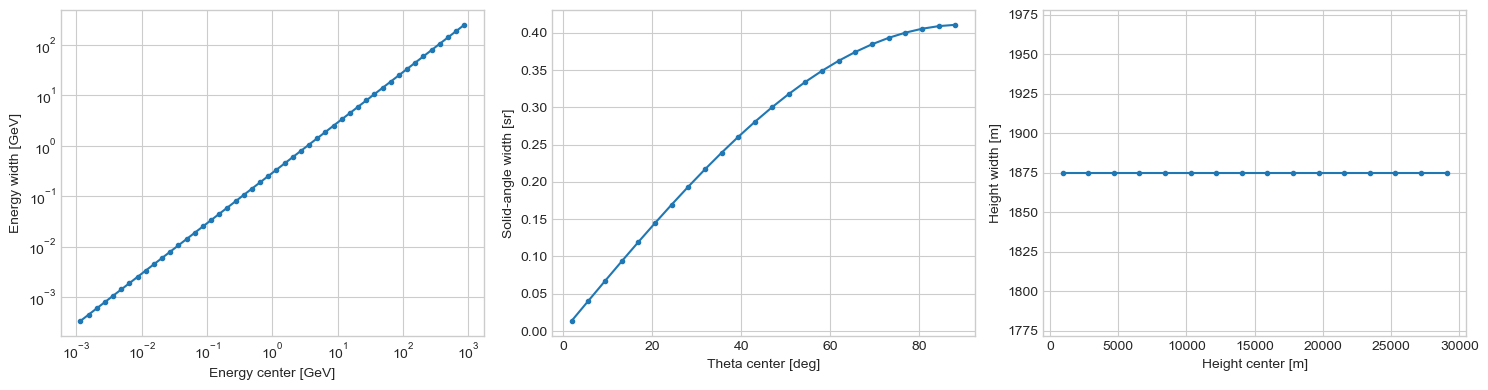

In [6]:
# Section 3 diagnostic: summarize grid geometry.
print(f"Energy range [GeV]: {energy_edges[0]:.3e} to {energy_edges[-1]:.3e}")
print(f"Theta range [deg]: {theta_edges[0]:.1f} to {theta_edges[-1]:.1f}")
print(f"Height range [m]: {h_edges[0]:.1f} to {h_edges[-1]:.1f}")
print(f"Solid-angle sum [sr]: {domega.sum():.6f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(energy_centers, energy_widths, marker=".")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Energy center [GeV]")
axes[0].set_ylabel("Energy width [GeV]")
axes[1].plot(theta_centers, domega, marker=".")
axes[1].set_xlabel("Theta center [deg]")
axes[1].set_ylabel("Solid-angle width [sr]")
axes[2].plot(h_centers, np.diff(h_edges), marker=".")
axes[2].set_xlabel("Height center [m]")
axes[2].set_ylabel("Height width [m]")
plt.tight_layout()
plt.show()


## 4. Campaign Loading

This section loads the CORSIKA manifest and keeps only successful events so the dataset is built from completed simulation outputs.

In [7]:
# Section 4 diagnostic: summarize successful campaign events.
manifest = pd.read_csv(CONFIG.manifest_path).drop_duplicates("event_id", keep="last")
if CONFIG.max_events is not None:
    manifest = manifest.head(CONFIG.max_events)
print("\n Loading Manifest file:", CONFIG.manifest_path)
print("\n Total events registered in Manifest:", len(manifest))
print()

display(manifest.sample(5))
print(f"Successful events used: {len(manifest)}")
if len(manifest):
    summary = (
        manifest
        .groupby("status")
        .agg(
            n_events=("event_id", "count"),
            mean_elapsed_seconds=("elapsed_seconds", "mean"),
            min_elapsed_seconds=("elapsed_seconds", "min"),
            max_elapsed_seconds=("elapsed_seconds", "max"),
            total_elapsed_seconds=("elapsed_seconds", "sum"),
        )
        .sort_values("n_events", ascending=False)
    )

    print("\nStatus summary:")
    display(summary)


 Loading Manifest file: V:\output\data\corsika\generator\run_2\manifest.csv

 Total events registered in Manifest: 40000



,event_id,status,returncode,output_dir,stdout_log,stderr_log,elapsed_seconds,command,corsika_id,primary_mnemonic,...,phi0_deg,observation_level_m,primary_weight,p_real,q_sim,importance_ratio,neutrino_total,neutrino_e,neutrino_mu,neutrino_tau
38044,58090,done,0,generator/run_2/event_00058090,generator/run_2/_logs/event_00058090/stdout.log,generator/run_2/_logs/event_00058090/stderr.log,21.874254,/home/juan/hep/opt/corsika8-install/bin/c8_tpe...,402,He,...,77.403837,41656.845335,0.000025,8.160690e-09,8.160690e-09,1.0,222,66,156,0
6642,9159,done,0,generator/run_2/event_00009159,generator/run_2/_logs/event_00009159/stdout.log,generator/run_2/_logs/event_00009159/stderr.log,14.005960,/home/juan/hep/opt/corsika8-install/bin/c8_tpe...,14,p,...,347.918423,91025.128591,0.000025,2.128948e-08,2.128948e-08,1.0,62,17,45,0
5360,7372,done,0,generator/run_2/event_00007372,generator/run_2/_logs/event_00007372/stdout.log,generator/run_2/_logs/event_00007372/stderr.log,10.050813,/home/juan/hep/opt/corsika8-install/bin/c8_tpe...,402,He,...,51.891274,91620.086999,0.000025,8.020500e-08,8.020500e-08,1.0,0,0,0,0
16585,28376,done,0,generator/run_2/event_00028376,generator/run_2/_logs/event_00028376/stdout.log,generator/run_2/_logs/event_00028376/stderr.log,19.138590,/home/juan/hep/opt/corsika8-install/bin/c8_tpe...,402,He,...,20.649091,4439.316984,0.000025,9.051102e-09,9.051102e-09,1.0,182,51,131,0
66,95,done,0,generator/run_2/event_00000095,generator/run_2/_logs/event_00000095/stdout.log,generator/run_2/_logs/event_00000095/stderr.log,9.314118,/home/juan/hep/opt/corsika8-install/bin/c8_tpe...,402,He,...,275.229336,89149.865357,0.000025,4.385688e-08,4.385688e-08,1.0,0,0,0,0


Successful events used: 40000

Status summary:


,n_events,mean_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds,total_elapsed_seconds
status,,,,,
done,39938,14.349302,8.087984,759.700511,573082.410411
failed,62,20.336788,0.092431,243.884179,1260.880834


## 5. Neutrino Extraction with Production Metadata

This section uses `tpeanuts/neutrino_production.parquet` as the base table. These rows represent neutrinos at production, so the dataset stores production height, emission direction, emission zenith angle, parent information, and primary metadata. The file `particles/particles.parquet` is not used here because it describes neutrinos that crossed the observation plane; that information is useful for observation-plane fluxes, but not needed for a production-based dataset.

The standard CORSIKA particle table contains `pdg`, `kinetic_energy`, direction cosines `nx`, `ny`, `nz`, and particle `weight`. For neutrinos, the kinetic energy is treated as $E_\nu$ because neutrino masses are negligible for this application.

The downward-going neutrino zenith angle is computed as:

$$
\theta_\nu = \arccos(-n_z).
$$


In [8]:
def primary_meta(event_id: int) -> dict[str, Any]:
    """Load primary metadata for one event.

    Args:
        event_id: Event identifier.

    Returns:
        Dictionary with primary metadata, or safe defaults if the file is missing.
    """
    event_id = int(event_id)
    cached_rows = globals().get("PRIMARY_META_BY_EVENT", {})
    if event_id in cached_rows:
        row = dict(cached_rows[event_id])
    else:
        manifest_rows = manifest[manifest["event_id"].astype(int) == event_id] if "event_id" in manifest else pd.DataFrame()
        row = manifest_rows.iloc[-1].to_dict() if not manifest_rows.empty else {}

    p = CONFIG.runs_root / "_primaries" / f"event_{event_id:08d}.csv"
    if p.exists():
        file_row = pd.read_csv(p).iloc[0].to_dict()
        row.update({k: v for k, v in file_row.items() if k not in row or pd.isna(row[k])})

    row.setdefault("primary_weight", 1.0)
    row.setdefault("observation_level_m", np.nan)
    row.setdefault("primary_mnemonic", row.get("species_mnemonic", "unknown"))
    row.setdefault("primary_name", row.get("species_name", "unknown"))
    row.setdefault("p_real", np.nan)
    row.setdefault("q_sim", np.nan)
    row.setdefault("importance_ratio", np.nan)
    return row


def resolve_event_dir(event_id: int, output_dir: Any) -> Path:
    """Resolve event directories from current or legacy manifest paths."""
    event_name = f"event_{int(event_id):08d}"
    raw_text = "" if pd.isna(output_dir) else str(output_dir).replace("\\", "/")
    raw_path = Path(raw_text) if raw_text else Path(event_name)

    candidates = []
    if raw_path.is_absolute() and raw_path.exists():
        return raw_path
    if raw_text:
        for marker in ["/corsika/generator/", "corsika/generator/"]:
            if marker in raw_text:
                candidates.append(OUTPUT_CORSIKA_ROOT / "generator" / raw_text.split(marker, 1)[1])
                break
        candidates.append(OUTPUT_CORSIKA_ROOT / raw_path)
    candidates.extend([
        CONFIG.runs_root / raw_path.name if raw_path.name else CONFIG.runs_root / event_name,
        CONFIG.runs_root / event_name,
    ])

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[-1]


def extract(event_id: int, event_dir: Path) -> pd.DataFrame:
    """Extract produced neutrinos from the TPEANUTS writer.

    Args:
        event_id: Event identifier.
        event_dir: Event output directory.

    Returns:
        DataFrame with produced-neutrino kinematics, production metadata, parent metadata, and weights.
    """
    p = event_dir / "tpeanuts" / "neutrino_production.parquet"
    if not p.exists():
        print(f"[WARNING] Event {event_id}. Missing TPEANUTS parquet: {p}")
        return pd.DataFrame()
    size = p.stat().st_size
    if size < 8:
        print(f"[WARNING] Event {event_id}. Corrupted TPEANUTS parquet (too small: {size} bytes): {p}")
        return pd.DataFrame()

    df = pd.read_parquet(p).copy()
    if df.empty:
        return df

    df = df.rename(columns={"neutrino_pdg": "pdg"})
    df = df[df["pdg"].isin(NEUTRINO_PDG.keys())].copy()
    if df.empty:
        return df

    m = primary_meta(event_id)
    df["event_id"] = event_id
    df["flavor"] = df["pdg"].map(NEUTRINO_PDG)
    df["flavor_index"] = df["flavor"].map(FIDX).astype(np.int16)
    df["E_nu_GeV"] = df["neutrino_energy_gev"].astype(float)
    df["theta_nu_deg"] = df["theta_emission_deg"].astype(float)
    df["h_production_m"] = df["h_production_m"].astype(float)
    df["h_observation_m"] = float(m.get("observation_level_m", np.nan))
    df["h_m"] = df["h_production_m"]

    df["x"] = df["x_production_m"].astype(float)
    df["y"] = df["y_production_m"].astype(float)
    df["z"] = df["z_production_m"].astype(float)
    df["nx"] = df["nx_emission"].astype(float)
    df["ny"] = df["ny_emission"].astype(float)
    df["nz"] = df["nz_emission"].astype(float)

    df["primary_weight"] = float(m.get("primary_weight", 1.0))
    df["corsika_particle_weight"] = df["neutrino_weight"].astype(float) if "neutrino_weight" in df else 1.0
    df["total_weight"] = df["primary_weight"] * df["corsika_particle_weight"]
    df["primary_mnemonic"] = str(m.get("primary_mnemonic", m.get("species_mnemonic", "unknown")))
    df["primary_name"] = str(m.get("primary_name", m.get("species_name", "unknown")))
    df["primary_E0_GeV"] = float(m.get("E0_GeV", np.nan))
    df["primary_theta0_deg"] = float(m.get("theta0_deg", np.nan))
    df["primary_phi0_deg"] = float(m.get("phi0_deg", np.nan))
    df["primary_p_real"] = float(m.get("p_real", np.nan))
    df["primary_q_sim"] = float(m.get("q_sim", np.nan))
    df["primary_importance_ratio"] = float(m.get("importance_ratio", np.nan))
    df["production_match_found"] = True
    return df


manifest = manifest[manifest["status"].isin(["done", "skipped_done"])].copy()
if "event_id" in manifest:
    manifest["event_id"] = manifest["event_id"].astype(int)
    PRIMARY_META_BY_EVENT = manifest.drop_duplicates("event_id", keep="last").set_index("event_id").to_dict("index")
else:
    PRIMARY_META_BY_EVENT = {}

event_jobs = [
    (ix, int(row.event_id), resolve_event_dir(int(row.event_id), row.output_dir))
    for ix, row in enumerate(manifest.itertuples(index=False))
]
max_workers = max(1, min(int(CONFIG.extraction_max_workers), len(event_jobs) or 1))
print(f"Events selected: {len(event_jobs):,}")
print(f"Parallel extraction workers: {max_workers}")


def extract_job(job: tuple[int, int, Path]) -> tuple[int, pd.DataFrame]:
    """Extract one event and return its manifest index so results can be re-ordered."""
    ix, event_id, event_dir = job
    return ix, extract(event_id, event_dir)


frames_by_index: dict[int, pd.DataFrame] = {}
if event_jobs:
    if max_workers == 1:
        iterator = tqdm(event_jobs, total=len(event_jobs), desc="Extracting neutrinos", unit="event") if tqdm else event_jobs
        for job in iterator:
            ix, frame = extract_job(job)
            frames_by_index[ix] = frame
    else:
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(extract_job, job) for job in event_jobs]
            iterator = tqdm(as_completed(futures), total=len(futures), desc="Extracting neutrinos", unit="event") if tqdm else as_completed(futures)
            for future in iterator:
                ix, frame = future.result()
                frames_by_index[ix] = frame

frames = [frames_by_index[ix] for ix, _, _ in event_jobs]
non_empty_frames = [frame for frame in frames if not frame.empty]
raw = pd.concat(non_empty_frames, ignore_index=True) if non_empty_frames else pd.DataFrame()
print("\n--> produced neutrinos", len(raw))
if not raw.empty:
    display(raw.head())


Events selected: 39,938
Parallel extraction workers: 32


Extracting neutrinos:   0%|          | 0/39938 [00:00<?, ?event/s]


--> produced neutrinos 2024863


,shower,production_id,neutrino_id,pdg,parent_pdg,parent_corsika_code,parent_A,parent_Z,neutrino_energy_gev,neutrino_kinetic_energy_gev,...,total_weight,primary_mnemonic,primary_name,primary_E0_GeV,primary_theta0_deg,primary_phi0_deg,primary_p_real,primary_q_sim,primary_importance_ratio,production_match_found
0,0,167,0,-14,-211,22,0,-1,0.369544,0.369544,...,0.000025,p,proton,111.917342,48.785592,45.054777,2.353700e-07,2.353700e-07,1.0,True
1,0,173,1,-12,13,5,0,-1,0.371062,0.371062,...,0.000025,p,proton,111.917342,48.785592,45.054777,2.353700e-07,2.353700e-07,1.0,True
2,0,173,2,14,13,5,0,-1,0.280944,0.280944,...,0.000025,p,proton,111.917342,48.785592,45.054777,2.353700e-07,2.353700e-07,1.0,True
3,0,5432,3,14,211,21,0,1,0.306693,0.306693,...,0.000025,p,proton,111.917342,48.785592,45.054777,2.353700e-07,2.353700e-07,1.0,True
4,0,5536,4,12,-13,6,0,1,0.632336,0.632336,...,0.000025,p,proton,111.917342,48.785592,45.054777,2.353700e-07,2.353700e-07,1.0,True


In [9]:
print(raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2024863 entries, 0 to 2024862
Data columns (total 52 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   shower                       uint32 
 1   production_id                int32  
 2   neutrino_id                  int32  
 3   pdg                          int32  
 4   parent_pdg                   int32  
 5   parent_corsika_code          int32  
 6   parent_A                     int32  
 7   parent_Z                     int32  
 8   neutrino_energy_gev          float32
 9   neutrino_kinetic_energy_gev  float32
 10  theta_emission_deg           float32
 11  phi_emission_deg             float32
 12  x_production_m               float32
 13  y_production_m               float32
 14  z_production_m               float32
 15  h_production_m               float64
 16  nx_emission                  float32
 17  ny_emission                  float32
 18  nz_emission                  float32
 19  

,events,rows,weight_sum
flavor,,,
anti_nu_e,26446,256033,6.325827
anti_nu_mu,26540,651195,16.089126
nu_e,26475,267244,6.602818
nu_mu,26540,660030,16.307413


Rows loaded from TPEANUTS production metadata: 1834502


,event_id,primary_mnemonic,primary_name,flavor,E_nu_GeV,theta_nu_deg,h_production_m,theta_emission_deg,parent_pdg,parent_energy_gev
0,17,p,proton,anti_nu_mu,0.369544,47.690662,26142.656250,47.690662,-211,1.390831
1,17,p,proton,anti_nu_e,0.371062,44.354347,24416.224609,44.354347,13,1.002484
2,17,p,proton,nu_mu,0.280944,44.448380,24416.224609,44.448380,13,1.002484
3,17,p,proton,nu_mu,0.306693,42.183109,26108.089844,42.183109,211,4.001055
4,17,p,proton,nu_e,0.632336,42.818768,12833.803711,42.818768,-13,2.990186


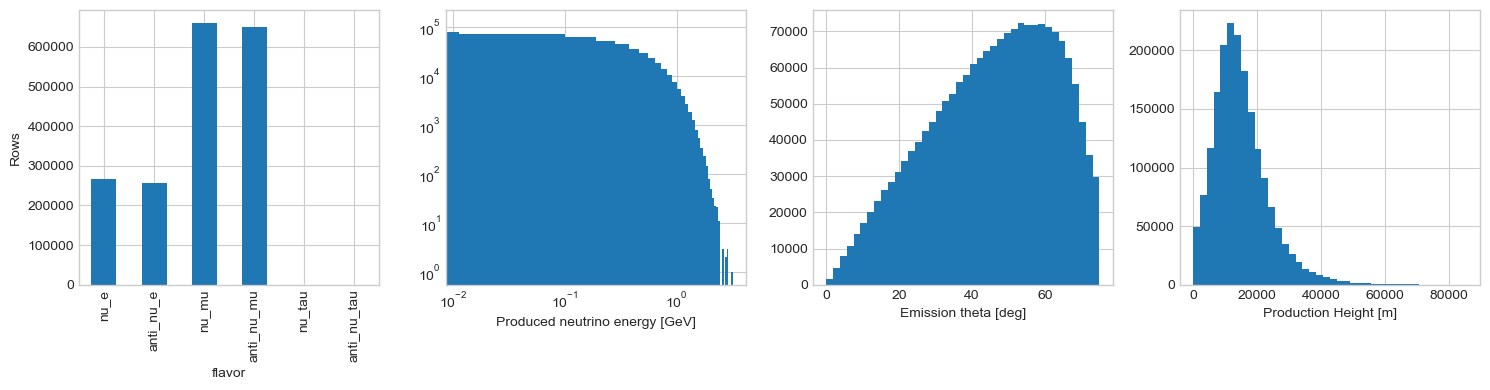

In [10]:
# Section 5 diagnostic: summarize extracted produced-neutrino rows.
raw = raw[raw['theta_nu_deg']<75]
if raw.empty:
    print("No produced-neutrino rows were extracted from the selected successful events.")
else:
    display(raw.groupby("flavor").agg(events=("event_id", "nunique"), rows=("event_id", "size"), weight_sum=("total_weight", "sum")))
    print(f"Rows loaded from TPEANUTS production metadata: {len(raw)}")
    display(raw[["event_id", "primary_mnemonic", "primary_name", "flavor", "E_nu_GeV", "theta_nu_deg", "h_production_m", "theta_emission_deg", "parent_pdg", "parent_energy_gev"]].head())
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    raw["flavor"].value_counts().reindex(FLAVORS, fill_value=0).plot(kind="bar", ax=axes[0])
    axes[0].set_ylabel("Rows")
    axes[1].hist(np.log10(raw["E_nu_GeV"]), bins=80)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    #axes[1].set_xlim(-3,4)
    axes[1].set_xlabel("Produced neutrino energy [GeV]")
    axes[2].hist(raw["theta_nu_deg"], bins=40)
    axes[2].set_xlabel("Emission theta [deg]")
    axes[3].hist(raw["h_production_m"], bins=40)
    axes[3].set_xlabel("Production Height [m]")
    plt.tight_layout()
    plt.show()


## 6. Torch-Ready Neutrino Table Dataset

This section stores the enriched per-neutrino table on disk. The Parquet file is the canonical table because it preserves all columns, names, categorical labels, and can be inspected with pandas. The compressed NumPy `.npz` file is a Torch-oriented numeric cache: it is faster to load with `np.load(...)` and convert with `torch.from_numpy(...)`, but it drops most string/object columns. They overlap, but they are useful for different workflows; if storage becomes an issue, keep Parquet and regenerate the `.npz` cache when needed.


In [11]:
def add_event_level_columns(neutrinos: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    """Add derived and event-level columns useful for Torch training."""
    if neutrinos.empty:
        return neutrinos
    out = neutrinos.copy()
    event_meta = manifest.drop_duplicates("event_id", keep="last").set_index("event_id") if "event_id" in manifest else pd.DataFrame()
    for target, source in {"primary_A": "A", "primary_Z": "Z", "primary_corsika_id": "corsika_id"}.items():
        if target not in out.columns and not event_meta.empty and source in event_meta.columns:
            out[target] = out["event_id"].map(event_meta[source])
    for column in ["primary_A", "primary_Z", "primary_corsika_id"]:
        if column not in out.columns:
            out[column] = np.nan
    out["primary_E0_per_nucleon_GeV"] = out["primary_E0_GeV"] / pd.to_numeric(out["primary_A"], errors="coerce").replace(0, np.nan)
    out["log10_E_nu_GeV"] = np.log10(np.clip(pd.to_numeric(out["E_nu_GeV"], errors="coerce"), 1e-30, None))
    out["log10_primary_E0_GeV"] = np.log10(np.clip(pd.to_numeric(out["primary_E0_GeV"], errors="coerce"), 1e-30, None))
    out["log10_total_weight"] = np.log10(np.clip(pd.to_numeric(out["total_weight"], errors="coerce"), 1e-300, None))
    out["log10_primary_importance_ratio"] = np.log10(np.clip(pd.to_numeric(out["primary_importance_ratio"], errors="coerce"), 1e-300, None))
    return out


def build_torch_numeric_arrays(neutrinos: pd.DataFrame) -> tuple[dict[str, np.ndarray], dict[str, Any]]:
    """Build numeric NumPy arrays and JSON-serializable metadata for Torch loading."""
    numeric_columns = [
        "event_id", "pdg", "flavor_index", "E_nu_GeV", "log10_E_nu_GeV", "theta_nu_deg",
        "h_observation_m", "h_production_m", "theta_emission_deg",
        "nx", "ny", "nz", "nx_emission", "ny_emission", "nz_emission",
        "x", "y", "z", "x_production_m", "y_production_m", "z_production_m",
        "primary_corsika_id", "primary_A", "primary_Z", "primary_E0_GeV",
        "primary_E0_per_nucleon_GeV", "log10_primary_E0_GeV", "primary_theta0_deg",
        "primary_phi0_deg", "primary_weight", "corsika_particle_weight", "total_weight",
        "log10_total_weight", "primary_p_real", "primary_q_sim", "primary_importance_ratio",
        "log10_primary_importance_ratio", "parent_pdg", "parent_A", "parent_Z",
        "parent_energy_gev", "parent_theta_deg", "parent_h_m", "parent_weight",
    ]
    arrays = {}
    for column in numeric_columns:
        if column in neutrinos.columns:
            arrays[column] = pd.to_numeric(neutrinos[column], errors="coerce").to_numpy(dtype=np.float32)
    species_categories = sorted(neutrinos["primary_mnemonic"].fillna("unknown").astype(str).unique().tolist())
    species_dtype = pd.CategoricalDtype(categories=species_categories)
    arrays["primary_species_code"] = neutrinos["primary_mnemonic"].fillna("unknown").astype(str).astype(species_dtype).cat.codes.to_numpy(dtype=np.int16)
    arrays["flavor_code"] = pd.Categorical(neutrinos["flavor"], categories=FLAVORS).codes.astype(np.int16)
    metadata = {
        "description": "Torch-ready per-neutrino table exported from CORSIKA TPEANUTS production metadata.",
        "parquet_path": str(CONFIG.neutrino_parquet_output_path),
        "npz_path": str(CONFIG.neutrino_npz_output_path),
        "rows": int(len(neutrinos)),
        "columns": list(neutrinos.columns),
        "numeric_arrays": sorted(arrays.keys()),
        "flavor_order": FLAVORS,
        "primary_species_order": species_categories,
        "weight_column": "total_weight",
        "importance_weight_column": "primary_importance_ratio",
        "source_manifest": str(CONFIG.manifest_path),
        "source_runs_root": str(CONFIG.runs_root),
    }
    return arrays, metadata


raw = add_event_level_columns(raw, manifest)

if raw.empty:
    print("No neutrinos available; torch-ready dataset files were not written.")
else:
    CONFIG.neutrino_parquet_output_path.parent.mkdir(parents=True, exist_ok=True)
    arrays, torch_metadata = build_torch_numeric_arrays(raw)
    if CONFIG.save_torch_parquet:
        raw.to_parquet(CONFIG.neutrino_parquet_output_path, index=False)
    if CONFIG.save_torch_npz:
        np.savez_compressed(CONFIG.neutrino_npz_output_path, **arrays)
    CONFIG.neutrino_metadata_path.write_text(json.dumps(torch_metadata, indent=2), encoding="utf-8")
    print("Torch-ready neutrino dataset saved")
    print("-" * 72)
    print(f"Parquet table: {CONFIG.neutrino_parquet_output_path if CONFIG.save_torch_parquet else 'disabled'}")
    print(f"NumPy arrays:  {CONFIG.neutrino_npz_output_path if CONFIG.save_torch_npz else 'disabled'}")
    print(f"Metadata JSON: {CONFIG.neutrino_metadata_path}")
    print(f"Rows:          {len(raw)}")
    print(f"Columns:       {len(raw.columns)}")
    print(f"Numeric arrays saved: {len(arrays)}")
    print(f"Primary species categories: {torch_metadata['primary_species_order']}")


Torch-ready neutrino dataset saved
------------------------------------------------------------------------
Parquet table: V:\output\data\difussion\dataset\run_2\dataset_neutrino_particles.parquet
NumPy arrays:  V:\output\data\difussion\dataset\run_2\dataset_neutrino_particles.npz
Metadata JSON: V:\output\data\difussion\dataset\run_2\dataset_neutrino_metadata.json
Rows:          1834502
Columns:       60
Numeric arrays saved: 46
Primary species categories: ['Al', 'C', 'He', 'Mg', 'N', 'O', 'Si', 'p']


In [12]:
# Section 6 diagnostic: verify saved torch-ready files.
if not raw.empty:
    assert CONFIG.neutrino_parquet_output_path.exists()
    assert CONFIG.neutrino_npz_output_path.exists()
    reloaded_for_torch = pd.read_parquet(CONFIG.neutrino_parquet_output_path)
    print(f"Reloaded rows: {len(reloaded_for_torch)}")
    print(f"Reloaded columns: {len(reloaded_for_torch.columns)}")
    with np.load(CONFIG.neutrino_npz_output_path) as arrays:
        print("Available numeric arrays:", sorted(arrays.files)[:12], "...")
        assert "E_nu_GeV" in arrays.files
    print("Section 6 test passed: torch-ready dataset files are readable.")


Reloaded rows: 1834502
Reloaded columns: 60
Available numeric arrays: ['E_nu_GeV', 'corsika_particle_weight', 'event_id', 'flavor_code', 'flavor_index', 'h_observation_m', 'h_production_m', 'log10_E_nu_GeV', 'log10_primary_E0_GeV', 'log10_primary_importance_ratio', 'log10_total_weight', 'nx'] ...
Section 6 test passed: torch-ready dataset files are readable.


## 7. Neutrino Dataset Visualization

This section defines a reusable visualization function for the per-neutrino dataset. The same function can be called with `weighted=False` for raw counts or `weighted=True` to use `total_weight`, which includes the primary importance weight and the CORSIKA particle weight.

Neutrino table dataset summary (unweighted)
------------------------------------------------------------------------
Rows: 1834502
Events: 26540
Primary species: ['Al', 'C', 'He', 'Mg', 'N', 'O', 'Si', 'p']
Flavors: ['anti_nu_e', 'anti_nu_mu', 'nu_e', 'nu_mu']


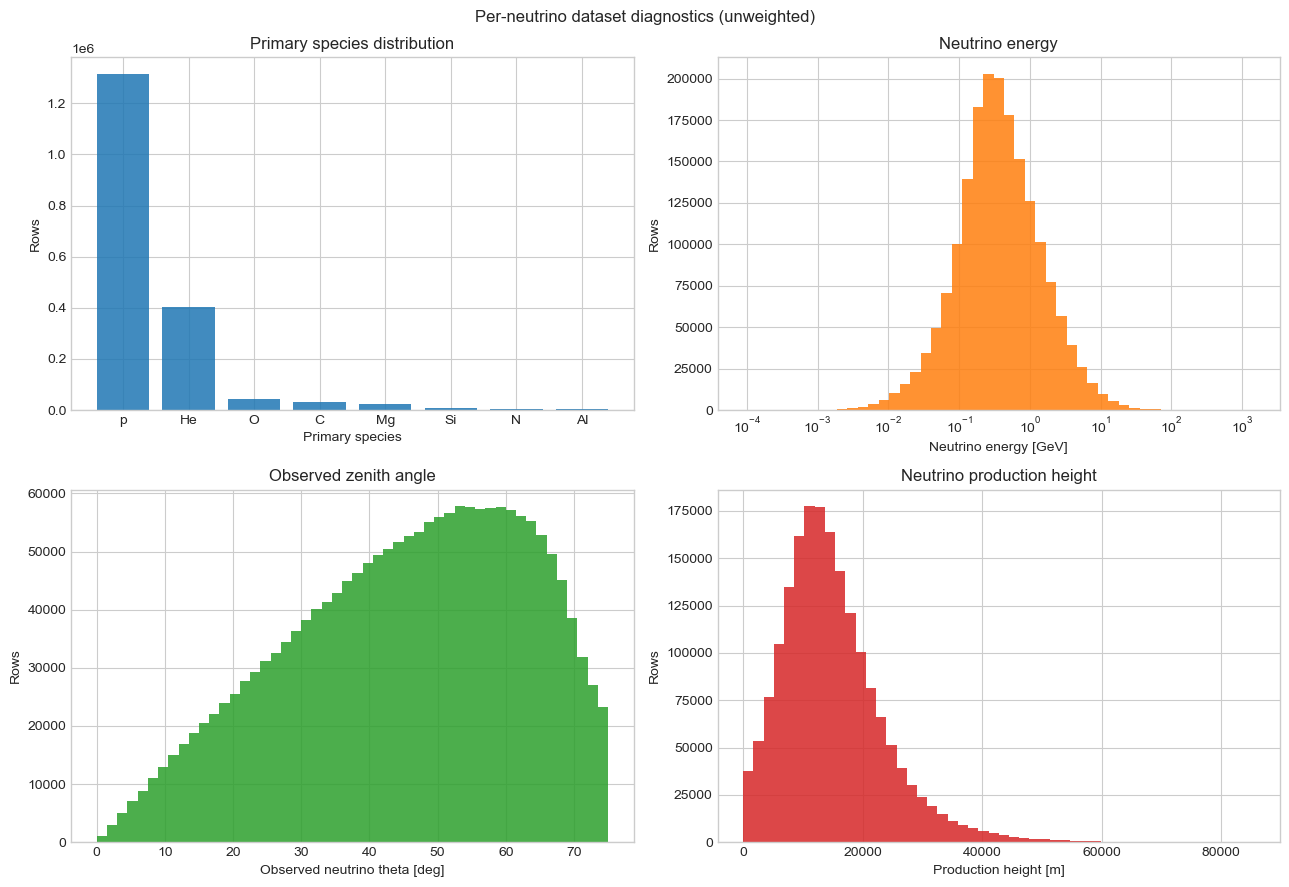

Neutrino table dataset summary (weighted)
------------------------------------------------------------------------
Rows: 1834502
Events: 26540
Primary species: ['Al', 'C', 'He', 'Mg', 'N', 'O', 'Si', 'p']
Flavors: ['anti_nu_e', 'anti_nu_mu', 'nu_e', 'nu_mu']
Weight sum: 4.532518e+01


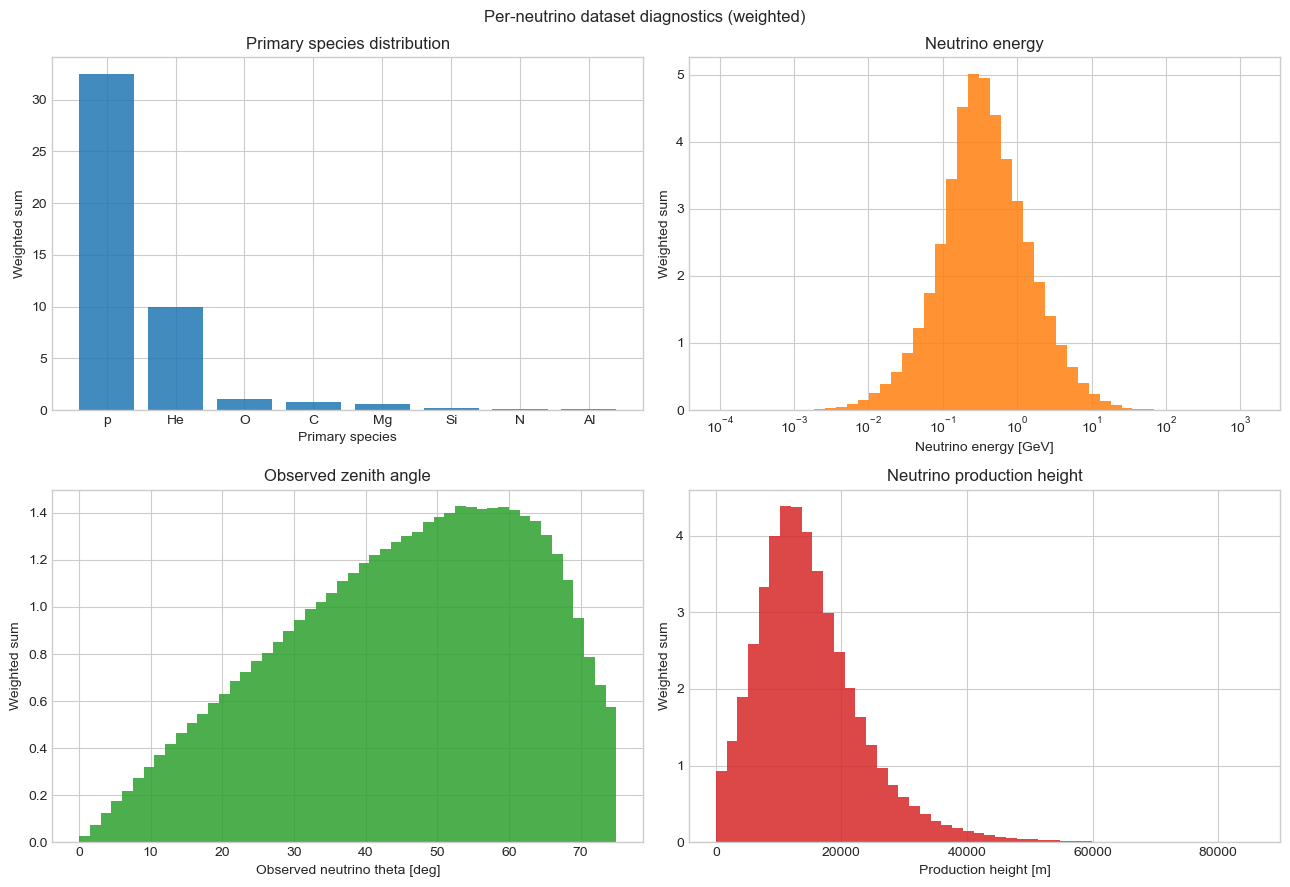

In [13]:
def visualize_neutrino_table_dataset(neutrinos: pd.DataFrame, weighted: bool = False, weight_column: str = "total_weight") -> None:
    """Visualize primary-species and neutrino distributions in the per-neutrino dataset.

    Args:
        neutrinos: Enriched per-neutrino table.
        weighted: Whether to weight histograms by `weight_column`.
        weight_column: Column used as histogram weights when `weighted=True`.

    Returns:
        None. Prints summaries and displays plots.
    """
    if neutrinos.empty:
        print("No neutrino rows available for visualization.")
        return

    weights = neutrinos[weight_column].to_numpy() if weighted and weight_column in neutrinos else None
    label = "weighted" if weights is not None else "unweighted"
    print(f"Neutrino table dataset summary ({label})")
    print("-" * 72)
    print(f"Rows: {len(neutrinos)}")
    print(f"Events: {neutrinos['event_id'].nunique()}")
    print(f"Primary species: {sorted(neutrinos['primary_mnemonic'].dropna().unique().tolist())}")
    print(f"Flavors: {sorted(neutrinos['flavor'].dropna().unique().tolist())}")
    if weights is not None:
        print(f"Weight sum: {np.nansum(weights):.6e}")

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    species_order = neutrinos["primary_mnemonic"].fillna("unknown").value_counts().index.tolist()
    species_values = []
    for species in species_order:
        mask = neutrinos["primary_mnemonic"].fillna("unknown") == species
        species_values.append(np.nansum(weights[mask]) if weights is not None else int(mask.sum()))
    axes[0, 0].bar(species_order, species_values, color="tab:blue", alpha=0.85)
    axes[0, 0].set_xlabel("Primary species")
    axes[0, 0].set_ylabel("Weighted sum" if weights is not None else "Rows")
    axes[0, 0].set_title("Primary species distribution")
    
    energy_bins = np.logspace(np.log10(neutrinos["E_nu_GeV"].dropna().min()), np.log10(neutrinos["E_nu_GeV"].dropna().max()), 50)
    axes[0, 1].hist(neutrinos["E_nu_GeV"].dropna(), bins=energy_bins, weights=weights[neutrinos["E_nu_GeV"].notna()] if weights is not None else None, color="tab:orange", alpha=0.85)
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_xlabel("Neutrino energy [GeV]")
    axes[0, 1].set_ylabel("Weighted sum" if weights is not None else "Rows")
    axes[0, 1].set_title("Neutrino energy")

    axes[1, 0].hist(neutrinos["theta_nu_deg"].dropna(), bins=50, weights=weights[neutrinos["theta_nu_deg"].notna()] if weights is not None else None, color="tab:green", alpha=0.85)
    axes[1, 0].set_xlabel("Observed neutrino theta [deg]")
    axes[1, 0].set_ylabel("Weighted sum" if weights is not None else "Rows")
    axes[1, 0].set_title("Observed zenith angle")

    h_column = "h_production_m" if "h_production_m" in neutrinos else "h_observation_m"
    valid_h = neutrinos[h_column].notna()
    axes[1, 1].hist(neutrinos.loc[valid_h, h_column], bins=50, weights=weights[valid_h] if weights is not None else None, color="tab:red", alpha=0.85)
    axes[1, 1].set_xlabel("Production height [m]" if h_column == "h_production_m" else "Observation height [m]")
    axes[1, 1].set_ylabel("Weighted sum" if weights is not None else "Rows")
    axes[1, 1].set_title("Neutrino production height")

    fig.suptitle(f"Per-neutrino dataset diagnostics ({label})")
    plt.tight_layout()
    plt.show()


visualize_neutrino_table_dataset(raw, weighted=False)
visualize_neutrino_table_dataset(raw, weighted=True)


## 8. Diffusion Cube Sample Construction

This section groups the per-neutrino table into event blocks. Each block of `CONFIG.cube_events_per_sample` CORSIKA events becomes one diffusion sample with shape `(n_channels, n_h, n_theta, n_energy)`, so the final tensor has shape `(n_samples, n_channels, n_h, n_theta, n_energy)`. Channels are the neutrino flavors in `FLAVORS`. For each sample, the notebook stores raw counts, weighted counts, sum of squared weights, differential flux, log-flux, relative uncertainty, a valid mask, and a condition vector.



In [14]:
def make_event_blocks(event_ids: np.ndarray, events_per_sample: int, stride: int) -> list[np.ndarray]:
    """Split event ids into possibly overlapping event blocks."""
    event_ids = np.asarray(sorted(np.unique(event_ids)), dtype=np.int64)
    if event_ids.size == 0:
        return []
    blocks = []
    for start in range(0, max(event_ids.size - events_per_sample + 1, 1), stride):
        block = event_ids[start:start + events_per_sample]
        if block.size:
            blocks.append(block)
    if blocks and blocks[-1][-1] != event_ids[-1] and event_ids.size >= events_per_sample:
        blocks.append(event_ids[-events_per_sample:])
    elif not blocks:
        blocks.append(event_ids)
    return blocks


def build_condition_table(block_neutrinos: pd.DataFrame, block_event_ids: np.ndarray, species_order: list[str]) -> dict[str, float]:
    """Build scalar and species-fraction conditions for one cube sample."""
    event_rows = block_neutrinos.drop_duplicates("event_id")
    loge0 = np.log10(np.clip(pd.to_numeric(event_rows["primary_E0_GeV"], errors="coerce"), 1e-30, None))
    theta0 = pd.to_numeric(event_rows["primary_theta0_deg"], errors="coerce")
    weights = pd.to_numeric(event_rows["primary_weight"], errors="coerce").fillna(0.0)
    condition = {
        "event_id_start": float(np.min(block_event_ids)),
        "event_id_end": float(np.max(block_event_ids)),
        "n_events": float(len(block_event_ids)),
        "n_events_with_neutrinos": float(block_neutrinos["event_id"].nunique()),
        "n_neutrinos": float(len(block_neutrinos)),
        "sum_primary_weight": float(weights.sum()),
        "mean_log10_E0": float(np.nanmean(loge0)) if len(loge0) else np.nan,
        "std_log10_E0": float(np.nanstd(loge0)) if len(loge0) else np.nan,
        "min_log10_E0": float(np.nanmin(loge0)) if len(loge0) else np.nan,
        "max_log10_E0": float(np.nanmax(loge0)) if len(loge0) else np.nan,
        "mean_theta0_deg": float(np.nanmean(theta0)) if len(theta0) else np.nan,
        "std_theta0_deg": float(np.nanstd(theta0)) if len(theta0) else np.nan,
    }
    species_counts = event_rows["primary_mnemonic"].fillna("unknown").astype(str).value_counts(normalize=True)
    for species in species_order:
        condition[f"species_fraction_{species}"] = float(species_counts.get(species, 0.0))
    return condition


def fill_cube_for_block(block_neutrinos: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fill raw-count, weighted-count, and sum-weights-squared cubes for one event block."""
    shape = (len(FLAVORS), CONFIG.h_bins, CONFIG.theta_bins, CONFIG.energy_bins)
    raw_counts = np.zeros(shape, dtype=np.int32)
    weighted_counts = np.zeros(shape, dtype=np.float32)
    sum_weights2 = np.zeros(shape, dtype=np.float32)
    if block_neutrinos.empty:
        return raw_counts, weighted_counts, sum_weights2
    ei = np.searchsorted(energy_edges, block_neutrinos["E_nu_GeV"], side="right") - 1
    ti = np.searchsorted(theta_edges, block_neutrinos["theta_nu_deg"], side="right") - 1
    hi = np.searchsorted(h_edges, block_neutrinos["h_m"], side="right") - 1
    fi = block_neutrinos["flavor_index"].to_numpy(dtype=np.int64)
    weights = pd.to_numeric(block_neutrinos[CONFIG.cube_weight_column], errors="coerce").fillna(0.0).to_numpy(dtype=np.float32)
    valid = (
        (fi >= 0) & (fi < len(FLAVORS)) &
        (ei >= 0) & (ei < CONFIG.energy_bins) &
        (ti >= 0) & (ti < CONFIG.theta_bins) &
        (hi >= 0) & (hi < CONFIG.h_bins) &
        np.isfinite(weights) & (weights > 0)
    )
    for f, h, t, e, w in zip(fi[valid], hi[valid], ti[valid], ei[valid], weights[valid]):
        raw_counts[f, h, t, e] += 1
        weighted_counts[f, h, t, e] += w
        sum_weights2[f, h, t, e] += w * w
    return raw_counts, weighted_counts, sum_weights2


species_order = sorted(raw["primary_mnemonic"].fillna("unknown").astype(str).unique().tolist()) if not raw.empty else []
event_ids_for_cubes = raw["event_id"].dropna().astype(int).unique() if not raw.empty else np.asarray([], dtype=np.int64)
event_blocks = make_event_blocks(event_ids_for_cubes, CONFIG.cube_events_per_sample, CONFIG.cube_event_stride)

cube_raw_counts, cube_weighted_counts, cube_sum_weights2, cube_conditions, kept_event_blocks = [], [], [], [], []
for block_event_ids in event_blocks:
    block_neutrinos = raw[raw["event_id"].isin(block_event_ids)].copy() if not raw.empty else pd.DataFrame()
    if len(block_neutrinos) < CONFIG.cube_min_neutrinos:
        continue
    raw_counts_i, weighted_counts_i, sum_weights2_i = fill_cube_for_block(block_neutrinos)
    cube_raw_counts.append(raw_counts_i)
    cube_weighted_counts.append(weighted_counts_i)
    cube_sum_weights2.append(sum_weights2_i)
    cube_conditions.append(build_condition_table(block_neutrinos, block_event_ids, species_order))
    kept_event_blocks.append(block_event_ids)

if cube_weighted_counts:
    cube_raw_counts = np.stack(cube_raw_counts, axis=0)
    cube_weighted_counts = np.stack(cube_weighted_counts, axis=0)
    cube_sum_weights2 = np.stack(cube_sum_weights2, axis=0)
else:
    cube_shape = (0, len(FLAVORS), CONFIG.h_bins, CONFIG.theta_bins, CONFIG.energy_bins)
    cube_raw_counts = np.zeros(cube_shape, dtype=np.int32)
    cube_weighted_counts = np.zeros(cube_shape, dtype=np.float32)
    cube_sum_weights2 = np.zeros(cube_shape, dtype=np.float32)

cube_denom = CONFIG.effective_area_m2 * CONFIG.exposure_time_s * domega[None, None, None, :, None] * energy_widths[None, None, None, None, :]
cube_flux = cube_weighted_counts / cube_denom
cube_support_mask = cube_weighted_counts > 0
cube_log10_flux = np.log10(cube_flux + 1e-300)
cube_log10_flux_floor_value = np.float32(CONFIG.cube_log10_flux_floor)
cube_log10_flux_valid = np.where(cube_support_mask, cube_log10_flux, cube_log10_flux_floor_value).astype(np.float32)
cube_log10_flux_floored = np.maximum(cube_log10_flux, cube_log10_flux_floor_value).astype(np.float32)
cube_log1p_weighted_counts = np.log1p(cube_weighted_counts).astype(np.float32)
cube_log1p_raw_counts = np.log1p(cube_raw_counts.astype(np.float32)).astype(np.float32)
cube_relative_uncertainty = np.divide(
    np.sqrt(cube_sum_weights2),
    cube_weighted_counts,
    out=np.full_like(cube_weighted_counts, np.nan, dtype=np.float32),
    where=cube_weighted_counts > 0,
)
cube_valid_mask = (
    (cube_raw_counts >= CONFIG.cube_min_counts_per_bin) &
    np.isfinite(cube_relative_uncertainty) &
    (cube_relative_uncertainty <= CONFIG.cube_max_relative_uncertainty)
)

condition_table = pd.DataFrame(cube_conditions)
condition_columns = condition_table.columns.tolist()
condition_array = condition_table.to_numpy(dtype=np.float32) if not condition_table.empty else np.zeros((0, 0), dtype=np.float32)
kept_event_start = np.asarray([block[0] for block in kept_event_blocks], dtype=np.int64) if kept_event_blocks else np.asarray([], dtype=np.int64)
kept_event_end = np.asarray([block[-1] for block in kept_event_blocks], dtype=np.int64) if kept_event_blocks else np.asarray([], dtype=np.int64)


Diffusion cube samples
------------------------------------------------------------------------
Events per sample : 800
Event stride      : 400
Samples kept      : 66
flux_cubes.shape  : (66, 6, 16, 24, 48) = (n_samples, n_channels, n_h, n_theta, n_energy)
Raw counts total  : 3,446,121
Weighted sum total: 8.514356e+01
Non-zero flux bins: 37985
Support fraction   : 0.155170
Valid-mask fraction: 0.155170
Log10 floor target : -12.0


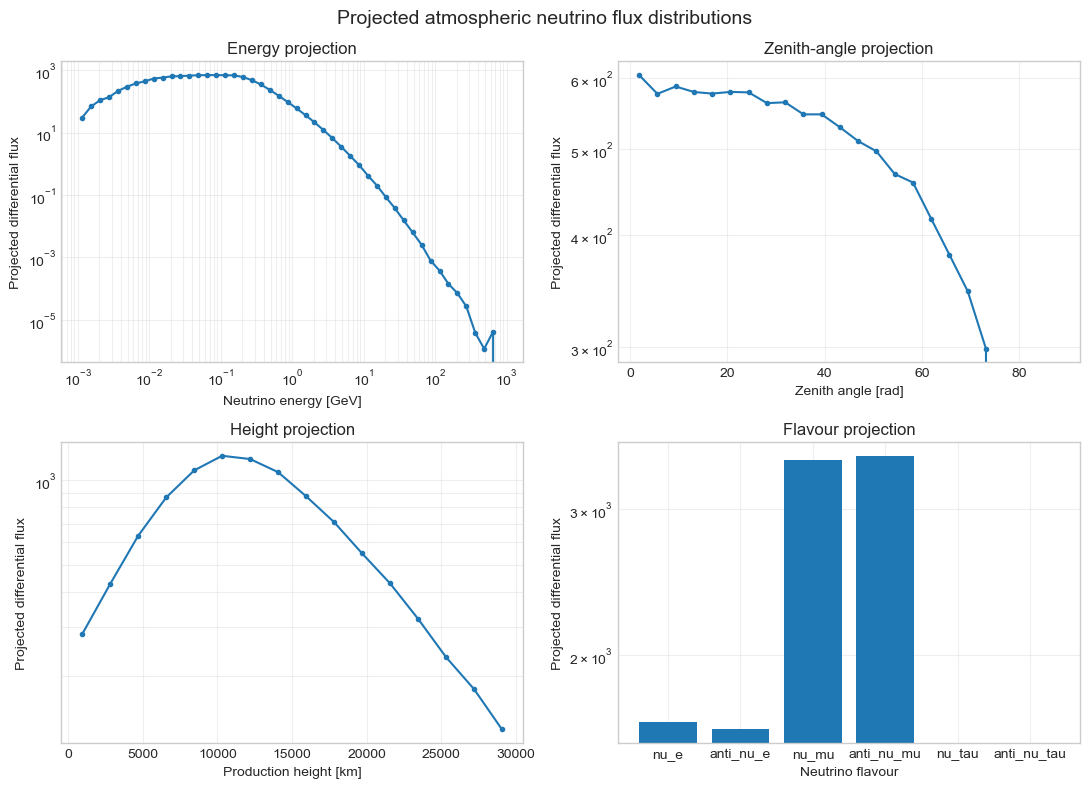

,event_id_start,event_id_end,n_events,n_events_with_neutrinos,n_neutrinos,sum_primary_weight,mean_log10_E0,std_log10_E0,min_log10_E0,max_log10_E0,mean_theta0_deg,std_theta0_deg,species_fraction_Al,species_fraction_C,species_fraction_He,species_fraction_Mg,species_fraction_N,species_fraction_O,species_fraction_Si,species_fraction_p
0,4.0,1683.0,800.0,800.0,56037.0,0.019766,2.296917,0.306318,2.001224,4.717238,44.883297,16.216058,0.0,0.00000,0.0700,0.0,0.0,0.00250,0.0,0.92750
1,848.0,2542.0,800.0,800.0,54709.0,0.019766,2.297903,0.305936,2.000645,4.717238,45.952115,16.774869,0.0,0.00000,0.0650,0.0,0.0,0.00250,0.0,0.93250
2,1684.0,3365.0,800.0,800.0,51891.0,0.019766,2.284569,0.288337,2.000388,3.728001,46.022797,16.615779,0.0,0.00125,0.0725,0.0,0.0,0.00375,0.0,0.92250
3,2543.0,4222.0,800.0,800.0,54384.0,0.019766,2.292997,0.293579,2.000388,3.793441,45.829021,15.691943,0.0,0.00250,0.0800,0.0,0.0,0.00250,0.0,0.91500
4,3368.0,5003.0,800.0,800.0,55027.0,0.019766,2.300131,0.299995,2.000234,3.848235,45.636324,15.874865,0.0,0.00250,0.0850,0.0,0.0,0.00125,0.0,0.91125


In [15]:

# Backward-compatible global names used by older diagnostics.
counts = cube_raw_counts.sum(axis=0) if cube_raw_counts.size else np.zeros((len(FLAVORS), CONFIG.h_bins, CONFIG.theta_bins, CONFIG.energy_bins), dtype=np.int64)
weighted = cube_weighted_counts.sum(axis=0) if cube_weighted_counts.size else np.zeros_like(counts, dtype=np.float32)
flux = weighted / (CONFIG.effective_area_m2 * CONFIG.exposure_time_s * domega[None, None, :, None] * energy_widths[None, None, None, :])
logflux = np.log10(flux + 1e-300)

print("Diffusion cube samples")
print("-" * 72)
print(f"Events per sample : {CONFIG.cube_events_per_sample}")
print(f"Event stride      : {CONFIG.cube_event_stride}")
print(f"Samples kept      : {cube_weighted_counts.shape[0]}")
print(f"flux_cubes.shape  : {cube_flux.shape} = (n_samples, n_channels, n_h, n_theta, n_energy)")
print(f"Raw counts total  : {cube_raw_counts.sum():,}")
print(f"Weighted sum total: {cube_weighted_counts.sum():.6e}")
# Section 6 diagnostic: inspect non-zero cube content.
print(f"Non-zero flux bins: {np.count_nonzero(flux)}")
print(f"Support fraction   : {cube_support_mask.mean():.6f}")
print(f"Valid-mask fraction: {cube_valid_mask.mean():.6f}")
print(f"Log10 floor target : {CONFIG.cube_log10_flux_floor}")

import numpy as np
import matplotlib.pyplot as plt

# flux shape: [flavour, height, theta, energy]
# axes:        0         1       2      3

if np.count_nonzero(flux):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    # ---------------------------------------------------------
    # 1. Energy projection
    # Sum over: flavour, height, theta
    # ---------------------------------------------------------
    ax = axes[0, 0]
    projected_energy = flux.sum(axis=(0, 1, 2))

    ax.plot(energy_centers, projected_energy, marker=".")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel("Projected differential flux")
    ax.set_title("Energy projection")

    # ---------------------------------------------------------
    # 2. Zenith-angle projection
    # Sum over: flavour, height, energy
    # ---------------------------------------------------------
    ax = axes[0, 1]
    projected_theta = flux.sum(axis=(0, 1, 3))

    ax.plot(theta_centers, projected_theta, marker=".")
    ax.set_yscale("log")
    ax.set_xlabel("Zenith angle [rad]")
    ax.set_ylabel("Projected differential flux")
    ax.set_title("Zenith-angle projection")

    # ---------------------------------------------------------
    # 3. Height projection
    # Sum over: flavour, theta, energy
    # ---------------------------------------------------------
    ax = axes[1, 0]
    projected_height = flux.sum(axis=(0, 2, 3))

    ax.plot(h_centers, projected_height, marker=".")
    ax.set_yscale("log")
    ax.set_xlabel("Production height [km]")
    ax.set_ylabel("Projected differential flux")
    ax.set_title("Height projection")

    # ---------------------------------------------------------
    # 4. Flavour projection
    # Sum over: height, theta, energy
    # ---------------------------------------------------------
    ax = axes[1, 1]
    projected_flavour = flux.sum(axis=(1, 2, 3))

    ax.bar(FLAVORS, projected_flavour)
    ax.set_yscale("log")
    ax.set_xlabel("Neutrino flavour")
    ax.set_ylabel("Projected differential flux")
    ax.set_title("Flavour projection")

    fig.suptitle("Projected atmospheric neutrino flux distributions", fontsize=14)

    for ax in axes.flat:
        ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

display(condition_table.head())



## 9. Diffusion Cube Storage

This section writes the diffusion-ready cube dataset to HDF5. The file stores many cube samples rather than one global cube. It includes weighted counts, raw counts, sum of squared weights, differential flux, log-flux, relative uncertainty, valid masks, event-block metadata, and conditioning vectors for conditional diffusion models.


In [16]:
CONFIG.neutrino_cubes_output_path.parent.mkdir(parents=True, exist_ok=True)
string_dtype = h5py.string_dtype("utf-8")

with h5py.File(CONFIG.neutrino_cubes_output_path, "w") as h5:
    h5.attrs["description"] = "Block-sampled CORSIKA neutrino flux cubes for diffusion training"
    h5.attrs["source_manifest"] = str(CONFIG.manifest_path)
    h5.attrs["source_runs_root"] = str(CONFIG.runs_root)
    h5.attrs["events_per_sample"] = CONFIG.cube_events_per_sample
    h5.attrs["event_stride"] = CONFIG.cube_event_stride
    h5.attrs["weight_column"] = CONFIG.cube_weight_column
    h5.attrs["log10_flux_floor"] = CONFIG.cube_log10_flux_floor
    h5.attrs["axis_order"] = "sample, channel/flavor, height, theta, energy"
    h5.create_dataset("grid/energy_edges_gev", data=energy_edges)
    h5.create_dataset("grid/energy_centers_gev", data=energy_centers)
    h5.create_dataset("grid/energy_widths_gev", data=energy_widths)
    h5.create_dataset("grid/theta_edges_deg", data=theta_edges)
    h5.create_dataset("grid/theta_centers_deg", data=theta_centers)
    h5.create_dataset("grid/h_edges_m", data=h_edges)
    h5.create_dataset("grid/h_centers_m", data=h_centers)
    h5.create_dataset("grid/solid_angle_widths_sr", data=domega)
    h5.create_dataset("grid/flavor_order", data=np.asarray(FLAVORS, dtype=object), dtype=string_dtype)
    h5.create_dataset("grid/channel_order", data=np.asarray(FLAVORS, dtype=object), dtype=string_dtype)
    chunk_shape = (1, len(FLAVORS), CONFIG.h_bins, CONFIG.theta_bins, CONFIG.energy_bins) if cube_flux.shape[0] else None
    h5.create_dataset("samples/weighted_counts", data=cube_weighted_counts, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/raw_counts", data=cube_raw_counts, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/sum_weights2", data=cube_sum_weights2, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/differential_flux", data=cube_flux, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/log10_differential_flux", data=cube_log10_flux, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/log10_differential_flux_floored", data=cube_log10_flux_floored, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/log10_differential_flux_valid", data=cube_log10_flux_valid, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/log1p_weighted_counts", data=cube_log1p_weighted_counts, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/log1p_raw_counts", data=cube_log1p_raw_counts, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/support_mask", data=cube_support_mask.astype(np.uint8), compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/relative_uncertainty", data=cube_relative_uncertainty, compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/valid_mask", data=cube_valid_mask.astype(np.uint8), compression="gzip", chunks=chunk_shape)
    h5.create_dataset("samples/condition", data=condition_array, compression="gzip")
    h5.create_dataset("samples/condition_columns", data=np.asarray(condition_columns, dtype=object), dtype=string_dtype)
    h5.create_dataset("samples/event_id_start", data=kept_event_start)
    h5.create_dataset("samples/event_id_end", data=kept_event_end)
    if not condition_table.empty:
        for column in ["n_events", "n_neutrinos", "sum_primary_weight"]:
            if column in condition_table:
                h5.create_dataset(f"samples/{column}", data=condition_table[column].to_numpy(dtype=np.float32))
    h5.create_dataset("global/weighted_counts", data=weighted, compression="gzip")
    h5.create_dataset("global/raw_counts", data=counts, compression="gzip")
    h5.create_dataset("global/differential_flux", data=flux, compression="gzip")
    h5.create_dataset("global/log10_differential_flux", data=logflux, compression="gzip")
    h5.create_dataset("global/log10_differential_flux_floored", data=np.maximum(logflux, CONFIG.cube_log10_flux_floor), compression="gzip")

print("Diffusion cube dataset saved")
print("-" * 72)
print(f"Path: {CONFIG.neutrino_cubes_output_path}")
print(f"Samples: {cube_flux.shape[0]}")
print(f"Sample tensor shape: {cube_flux.shape[1:] if cube_flux.shape[0] else 'empty'}")


Diffusion cube dataset saved
------------------------------------------------------------------------
Path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
Samples: 66
Sample tensor shape: (6, 16, 24, 48)


In [17]:
# Section 9 diagnostic: reopen the saved HDF5 dataset and verify key tensors.
with h5py.File(CONFIG.neutrino_cubes_output_path, "r") as h5:
    print("Top-level groups:", sorted(h5.keys()))
    print("Sample flux shape:", h5["samples/differential_flux"].shape)
    print("Condition shape:", h5["samples/condition"].shape)
    print("Flavor order:", [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in h5["grid/flavor_order"][:]])
    assert h5["samples/differential_flux"].shape == cube_flux.shape
    assert h5["samples/raw_counts"].shape == cube_raw_counts.shape
    assert h5["samples/valid_mask"].shape == cube_valid_mask.shape
print("Section 9 test passed: diffusion cube HDF5 file is readable.")


Top-level groups: ['global', 'grid', 'samples']
Sample flux shape: (66, 6, 16, 24, 48)
Condition shape: (66, 20)
Flavor order: ['nu_e', 'anti_nu_e', 'nu_mu', 'anti_nu_mu', 'nu_tau', 'anti_nu_tau']
Section 9 test passed: diffusion cube HDF5 file is readable.


## 10. PyTorch Dataset Loader

This section defines a small `torch.utils.data.Dataset` wrapper for the HDF5 diffusion cube file. It returns a cube tensor, the conditioning vector, the valid mask, and the sample index. The loader opens the HDF5 file inside `__getitem__`, which is robust with PyTorch dataloaders using worker processes.


In [18]:
class NeutrinoCubeH5Dataset(Dataset):
    """PyTorch Dataset for block-sampled CORSIKA neutrino diffusion cubes."""

    def __init__(self, path: str | Path, target: str = "log10_differential_flux"):
        self.path = Path(path)
        self.target = target
        with h5py.File(self.path, "r") as h5:
            self.n_samples = int(h5[f"samples/{target}"].shape[0])
            self.condition_columns = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in h5["samples/condition_columns"][:]]
            self.flavor_order = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in h5["grid/flavor_order"][:]]

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        with h5py.File(self.path, "r") as h5:
            x = torch.from_numpy(h5[f"samples/{self.target}"][idx]).float()
            condition = torch.from_numpy(h5["samples/condition"][idx]).float()
            valid_mask = torch.from_numpy(h5["samples/valid_mask"][idx].astype(bool))
            raw_counts = torch.from_numpy(h5["samples/raw_counts"][idx]).float()
            rel_unc = torch.from_numpy(h5["samples/relative_uncertainty"][idx]).float()
        return {"x": x, "condition": condition, "valid_mask": valid_mask, "raw_counts": raw_counts, "relative_uncertainty": rel_unc, "index": torch.tensor(idx, dtype=torch.long)}


cube_dataset = NeutrinoCubeH5Dataset(CONFIG.neutrino_cubes_output_path)
print("NeutrinoCubeH5Dataset")
print("-" * 72)
print(f"Path: {cube_dataset.path}")
print(f"Samples: {len(cube_dataset)}")
print(f"Target: {cube_dataset.target}")
print(f"Flavors: {cube_dataset.flavor_order}")
print(f"Condition columns: {cube_dataset.condition_columns[:12]}{' ...' if len(cube_dataset.condition_columns) > 12 else ''}")
if len(cube_dataset):
    sample = cube_dataset[0]
    print("Sample keys:", sample.keys())
    print("x shape:", tuple(sample["x"].shape))
    print("condition shape:", tuple(sample["condition"].shape))
    print("valid mask fraction:", sample["valid_mask"].float().mean().item())


NeutrinoCubeH5Dataset
------------------------------------------------------------------------
Path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
Samples: 66
Target: log10_differential_flux
Flavors: ['nu_e', 'anti_nu_e', 'nu_mu', 'anti_nu_mu', 'nu_tau', 'anti_nu_tau']
Condition columns: ['event_id_start', 'event_id_end', 'n_events', 'n_events_with_neutrinos', 'n_neutrinos', 'sum_primary_weight', 'mean_log10_E0', 'std_log10_E0', 'min_log10_E0', 'max_log10_E0', 'mean_theta0_deg', 'std_theta0_deg'] ...
Sample keys: dict_keys(['x', 'condition', 'valid_mask', 'raw_counts', 'relative_uncertainty', 'index'])
x shape: (6, 16, 24, 48)
condition shape: (20,)
valid mask fraction: 0.15431496500968933


## 11. Dataset Test and Visualization

This section verifies the diffusion-cube dataset and visualizes one selected sample. It reports global dataset statistics, checks one PyTorch sample, plots the selected sample support and uncertainty, and shows three 2D cube slices at fixed energy, fixed production height, and fixed zenith angle.


Dataset-level statistics
------------------------------------------------------------------------
Dataset path: V:\output\data\difussion\dataset\run_2\dataset_neutrino_cubes.h5
Number of samples: 66
Sample tensor shape: (6, 16, 24, 48)
Condition vector shape: (20,)
Flavor order: ['nu_e', 'anti_nu_e', 'nu_mu', 'anti_nu_mu', 'nu_tau', 'anti_nu_tau']
Energy bins: 48, theta bins: 24, height bins: 16


,n_events,n_neutrinos,sum_primary_weight,mean_log10_E0,mean_theta0_deg
count,66.0,66.000000,66.000000,66.000000,66.000000
mean,800.0,55258.212121,0.019766,2.301574,45.263320
std,0.0,2825.158542,0.000000,0.011332,0.588788
min,800.0,47943.000000,0.019766,2.267559,43.837952
25%,800.0,53507.750000,0.019766,2.296729,44.882378
50%,800.0,54954.000000,0.019766,2.300839,45.355475
75%,800.0,57140.250000,0.019766,2.305405,45.707743
max,800.0,63369.000000,0.019766,2.333534,46.370335


,sample_index,total_raw_counts,total_weighted_sum,valid_fraction_all_channels,flavor,flavor_raw_counts,flavor_weighted_sum,flavor_nonzero_bins,flavor_valid_fraction,median_relative_uncertainty,min_relative_uncertainty,max_relative_uncertainty
0,0,53493,1.321656,0.154315,nu_mu,19190,0.474129,5168,0.280382,0.707107,0.182574,1.0


Selected sample condition vector


,event_id_start,event_id_end,n_events,n_events_with_neutrinos,n_neutrinos,sum_primary_weight,mean_log10_E0,std_log10_E0,min_log10_E0,max_log10_E0,mean_theta0_deg,std_theta0_deg,species_fraction_Al,species_fraction_C,species_fraction_He,species_fraction_Mg,species_fraction_N,species_fraction_O,species_fraction_Si,species_fraction_p
0,4.0,1683.0,800.0,800.0,56037.0,0.019766,2.296917,0.306318,2.001224,4.717238,44.883297,16.216058,0.0,0.0,0.07,0.0,0.0,0.0025,0.0,0.9275


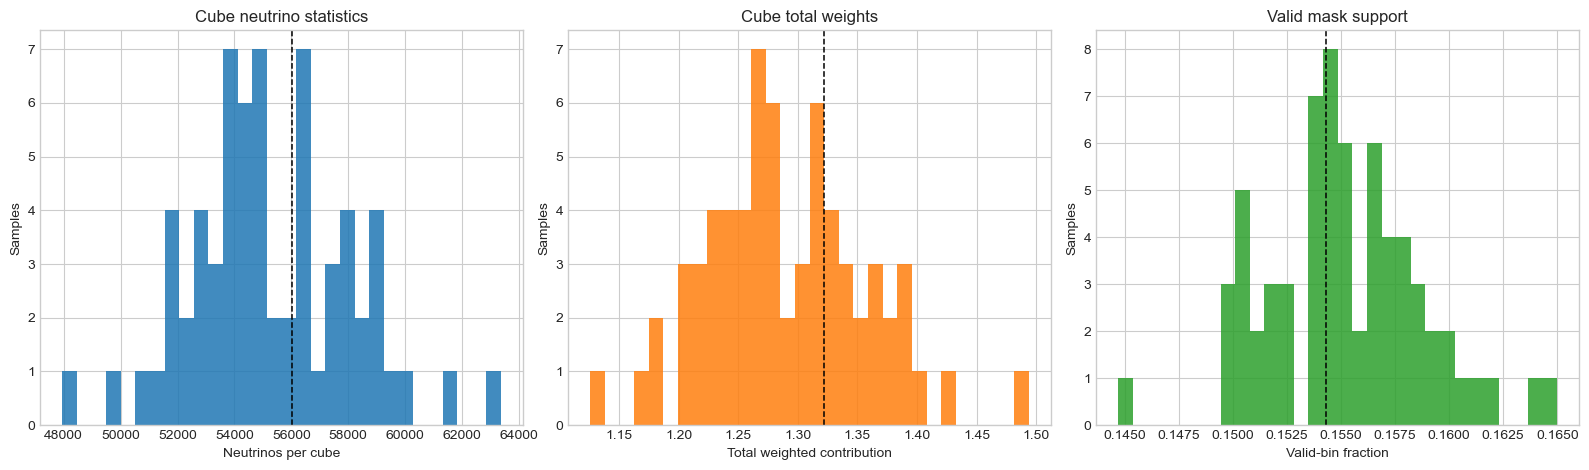

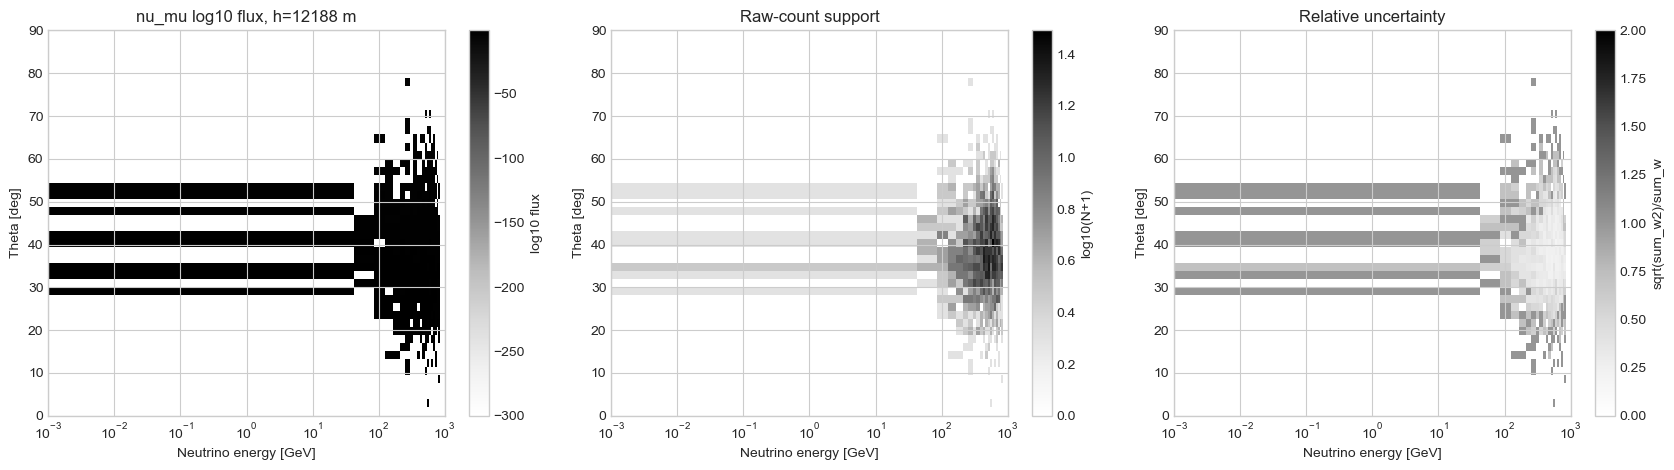

In [19]:
DATASET_TEST_SAMPLE_INDEX = 0
DATASET_TEST_FLAVOR = "nu_mu"
DATASET_TEST_ENERGY_GEV = 1.0e2
DATASET_TEST_HEIGHT_M = 15_000.0
DATASET_TEST_THETA_DEG = 45.0


def nearest_index(grid, value) -> int:
    """Return the index of the grid point nearest to value."""
    grid_array = np.asarray(grid, dtype=float)
    return int(np.nanargmin(np.abs(grid_array - float(value))))


def describe_sample(sample_index: int, flavor_idx: int) -> pd.DataFrame:
    """Return compact statistics for one cube sample and one flavor channel."""
    sample_counts = cube_raw_counts[sample_index]
    sample_weighted = cube_weighted_counts[sample_index]
    sample_rel_unc = cube_relative_uncertainty[sample_index]
    flavor_counts = sample_counts[flavor_idx]
    flavor_weighted = sample_weighted[flavor_idx]
    flavor_rel_unc = sample_rel_unc[flavor_idx]
    return pd.DataFrame(
        [
            {
                "sample_index": sample_index,
                "total_raw_counts": int(sample_counts.sum()),
                "total_weighted_sum": float(sample_weighted.sum()),
                "valid_fraction_all_channels": float(cube_valid_mask[sample_index].mean()),
                "flavor": FLAVORS[flavor_idx],
                "flavor_raw_counts": int(flavor_counts.sum()),
                "flavor_weighted_sum": float(flavor_weighted.sum()),
                "flavor_nonzero_bins": int(np.count_nonzero(flavor_counts)),
                "flavor_valid_fraction": float(cube_valid_mask[sample_index, flavor_idx].mean()),
                "median_relative_uncertainty": float(np.nanmedian(flavor_rel_unc)),
                "min_relative_uncertainty": float(np.nanmin(flavor_rel_unc)) if np.isfinite(flavor_rel_unc).any() else np.nan,
                "max_relative_uncertainty": float(np.nanmax(flavor_rel_unc)) if np.isfinite(flavor_rel_unc).any() else np.nan,
            }
        ]
    )


if len(cube_dataset) == 0:
    print("No diffusion cube samples are available. Increase event statistics or lower cube_min_neutrinos.")
else:
    sample_index = min(DATASET_TEST_SAMPLE_INDEX, len(cube_dataset) - 1)
    flavor_idx = FLAVORS.index(DATASET_TEST_FLAVOR) if DATASET_TEST_FLAVOR in FLAVORS else 0
    flavor_name = FLAVORS[flavor_idx]
    sample = cube_dataset[sample_index]

    print("Dataset-level statistics")
    print("-" * 72)
    print(f"Dataset path: {CONFIG.neutrino_cubes_output_path}")
    print(f"Number of samples: {len(cube_dataset):,}")
    print(f"Sample tensor shape: {tuple(sample['x'].shape)}")
    print(f"Condition vector shape: {tuple(sample['condition'].shape)}")
    print(f"Flavor order: {FLAVORS}")
    print(f"Energy bins: {CONFIG.energy_bins}, theta bins: {CONFIG.theta_bins}, height bins: {CONFIG.h_bins}")

    if not condition_table.empty:
        display(condition_table[[c for c in ["n_events", "n_neutrinos", "sum_primary_weight", "mean_log10_E0", "mean_theta0_deg"] if c in condition_table]].describe())

    display(describe_sample(sample_index, flavor_idx))
    if not condition_table.empty:
        print("Selected sample condition vector")
        display(pd.DataFrame([condition_table.iloc[sample_index].to_dict()]))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    if not condition_table.empty and "n_neutrinos" in condition_table:
        axes[0].hist(condition_table["n_neutrinos"], bins=30, color="tab:blue", alpha=0.85)
        axes[0].axvline(condition_table.iloc[sample_index]["n_neutrinos"], color="black", linestyle="--", lw=1.1)
        axes[0].set_xlabel("Neutrinos per cube")
        axes[0].set_ylabel("Samples")
        axes[0].set_title("Cube neutrino statistics")
    else:
        axes[0].set_axis_off()

    sample_weight_sums = cube_weighted_counts.sum(axis=(1, 2, 3, 4))
    axes[1].hist(sample_weight_sums, bins=30, color="tab:orange", alpha=0.85)
    axes[1].axvline(sample_weight_sums[sample_index], color="black", linestyle="--", lw=1.1)
    axes[1].set_xlabel("Total weighted contribution")
    axes[1].set_ylabel("Samples")
    axes[1].set_title("Cube total weights")

    valid_fraction = cube_valid_mask.mean(axis=(1, 2, 3, 4)) if cube_valid_mask.size else np.asarray([])
    axes[2].hist(valid_fraction, bins=30, color="tab:green", alpha=0.85)
    axes[2].axvline(valid_fraction[sample_index], color="black", linestyle="--", lw=1.1)
    axes[2].set_xlabel("Valid-bin fraction")
    axes[2].set_ylabel("Samples")
    axes[2].set_title("Valid mask support")
    plt.tight_layout()
    plt.show()

    height_idx = int(np.argmax(cube_raw_counts[sample_index, flavor_idx].sum(axis=(1, 2))))
    extent = [energy_edges[0], energy_edges[-1], theta_edges[0], theta_edges[-1]]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    im0 = axes[0].imshow(cube_log10_flux[sample_index, flavor_idx, height_idx].T, origin="lower", aspect="auto", extent=extent, interpolation="nearest")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Neutrino energy [GeV]")
    axes[0].set_ylabel("Theta [deg]")
    axes[0].set_title(f"{flavor_name} log10 flux, h={h_centers[height_idx]:.0f} m")
    fig.colorbar(im0, ax=axes[0], label="log10 flux")

    im1 = axes[1].imshow(np.log10(cube_raw_counts[sample_index, flavor_idx, height_idx].T + 1), origin="lower", aspect="auto", extent=extent, interpolation="nearest")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Neutrino energy [GeV]")
    axes[1].set_ylabel("Theta [deg]")
    axes[1].set_title("Raw-count support")
    fig.colorbar(im1, ax=axes[1], label="log10(N+1)")

    im2 = axes[2].imshow(cube_relative_uncertainty[sample_index, flavor_idx, height_idx].T, origin="lower", aspect="auto", extent=extent, interpolation="nearest", vmin=0, vmax=CONFIG.cube_max_relative_uncertainty * 2)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Neutrino energy [GeV]")
    axes[2].set_ylabel("Theta [deg]")
    axes[2].set_title("Relative uncertainty")
    fig.colorbar(im2, ax=axes[2], label="sqrt(sum_w2)/sum_w")
    plt.tight_layout()
    plt.show()


C:\Users\juanr\AppData\Local\Temp\ipykernel_9508\744985514.py:21: RuntimeWarning: divide by zero encountered in log10
  cube_sumE = np.log10(cube.sum(axis=2))
C:\Users\juanr\AppData\Local\Temp\ipykernel_9508\744985514.py:22: RuntimeWarning: divide by zero encountered in log10
  cube_sumH = np.log10(cube.sum(axis=0))
C:\Users\juanr\AppData\Local\Temp\ipykernel_9508\744985514.py:23: RuntimeWarning: divide by zero encountered in log10
  cube_sumTheta = np.log10(cube.sum(axis=1))


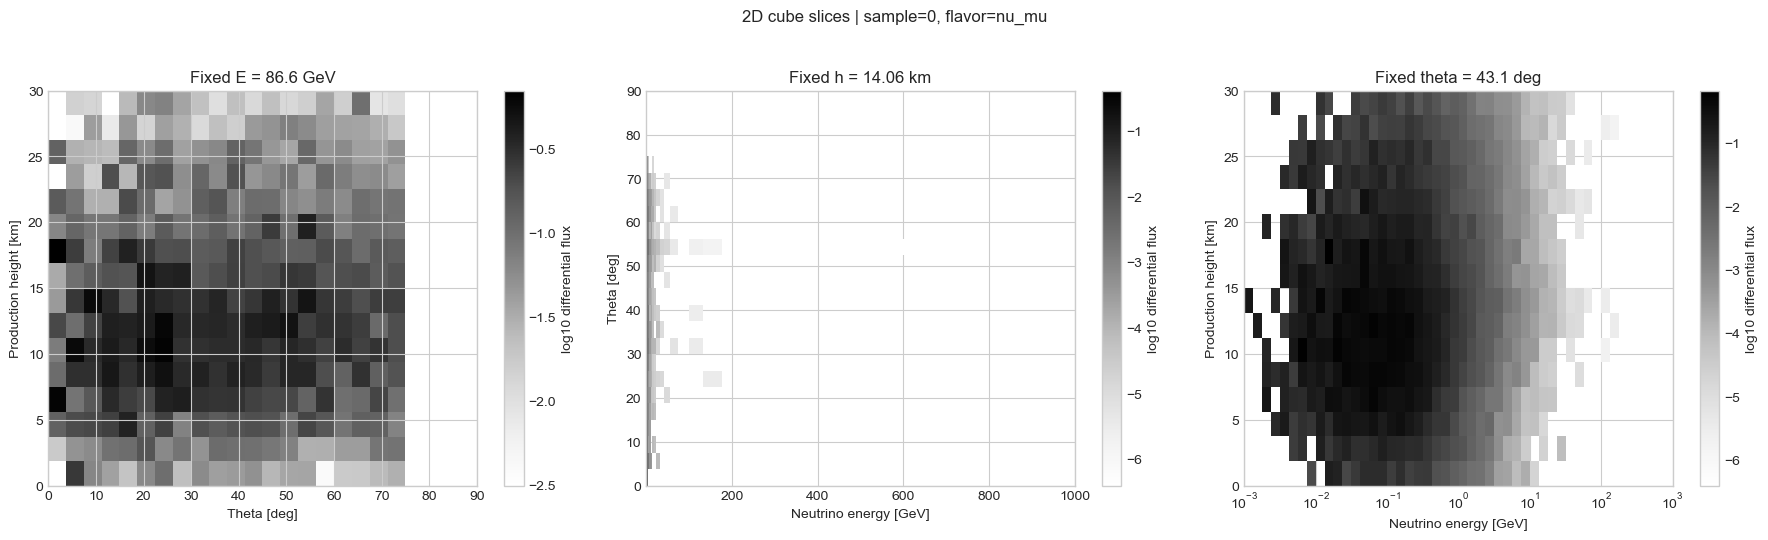

2D slice support checks
------------------------------------------------------------------------
Sample index: 0
Flavor: nu_mu
Energy slice: requested=100 GeV, grid=86.6 GeV, raw counts=0
Height slice: requested=15000.0 m, grid=14062.5 m, raw counts=2,256
Theta slice: requested=45.0 deg, grid=43.1 deg, raw counts=1,375


In [20]:
# 2D cube slices at fixed energy, height, and angle.
if len(cube_dataset) == 0:
    print("No diffusion cube samples are available for 2D slice visualization.")
else:
    sample_idx = min(DATASET_TEST_SAMPLE_INDEX, len(cube_dataset) - 1)
    flavor_idx = FLAVORS.index(DATASET_TEST_FLAVOR) if DATASET_TEST_FLAVOR in FLAVORS else 0
    flavor_name = FLAVORS[flavor_idx]
    e_idx = nearest_index(energy_centers, DATASET_TEST_ENERGY_GEV)
    h_idx = nearest_index(h_centers, DATASET_TEST_HEIGHT_M)
    theta_idx = nearest_index(theta_centers, DATASET_TEST_THETA_DEG)

    cube = cube_log10_flux[sample_idx, flavor_idx]
    
    cube = cube_flux[sample_idx, flavor_idx]
    
    
    
    raw_support = cube_raw_counts[sample_idx, flavor_idx]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    cube_sumE = np.log10(cube.sum(axis=2))
    cube_sumH = np.log10(cube.sum(axis=0))
    cube_sumTheta = np.log10(cube.sum(axis=1))
    im0 = axes[0].imshow(
        #cube[:, :, e_idx],
        cube_sumE,
        origin="lower",
        aspect="auto",
        extent=[theta_edges[0], theta_edges[-1], h_edges[0] / 1000.0, h_edges[-1] / 1000.0],
        interpolation="nearest",
    )
    axes[0].set_xlabel("Theta [deg]")
    axes[0].set_ylabel("Production height [km]")
    axes[0].set_title(f"Fixed E = {energy_centers[e_idx]:.3g} GeV")
    fig.colorbar(im0, ax=axes[0], label="log10 differential flux")

    """
    im1 = axes[1].imshow(
        #cube[:, h_idx, :],
        cube_sumH,
        origin="lower",
        aspect="auto",
        extent=[energy_edges[0], energy_edges[-1], theta_edges[0], theta_edges[-1]],
        interpolation="nearest",
    )
    """
    im1 = axes[1].pcolormesh(
        energy_edges,
        theta_edges,
        cube_sumH,
        shading="auto",   
    )
    
    
    #axes[1].set_xscale("log")
    axes[1].set_xlabel("Neutrino energy [GeV]")
    axes[1].set_ylabel("Theta [deg]")
    axes[1].set_title(f"Fixed h = {h_centers[h_idx] / 1000.0:.2f} km")
    fig.colorbar(im1, ax=axes[1], label="log10 differential flux")

    im2 = axes[2].pcolormesh(
        energy_edges,
        h_edges / 1000.0,
        cube_sumTheta,
        shading="auto",
    )
    
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Neutrino energy [GeV]")
    axes[2].set_ylabel("Production height [km]")
    axes[2].set_title(f"Fixed theta = {theta_centers[theta_idx]:.1f} deg")
    fig.colorbar(im2, ax=axes[2], label="log10 differential flux")

    fig.suptitle(f"2D cube slices | sample={sample_idx}, flavor={flavor_name}", y=1.03)
    plt.tight_layout()
    plt.show()

    print("2D slice support checks")
    print("-" * 72)
    print(f"Sample index: {sample_idx}")
    print(f"Flavor: {flavor_name}")
    print(f"Energy slice: requested={DATASET_TEST_ENERGY_GEV:.3g} GeV, grid={energy_centers[e_idx]:.3g} GeV, raw counts={raw_support[:, :, e_idx].sum():,}")
    print(f"Height slice: requested={DATASET_TEST_HEIGHT_M:.1f} m, grid={h_centers[h_idx]:.1f} m, raw counts={raw_support[h_idx].sum():,}")
    print(f"Theta slice: requested={DATASET_TEST_THETA_DEG:.1f} deg, grid={theta_centers[theta_idx]:.1f} deg, raw counts={raw_support[:, theta_idx, :].sum():,}")
